In [37]:
import pandas as pd
import numpy as np

In [38]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "processed_timeseries_table_timeseries_table " + "(10)" + ".csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lsobieski/processed-thermostat-data",
  file_path,
)

df.head()

,Timestamp,Temperature,Setpoint,FanState,OutputState,RunningMode_cool,RunningMode_heat,RunningMode_off,CumulativeRuntime,CumulativeCost,Outdoor_Temperature,outsideMinTemp,outsideMaxTemp,outsideHumidity
0,2025-02-13 12:32:53,24.150,24.44,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.052000,-1.44,0.58,71.0
1,2025-02-13 12:33:29,23.860,24.44,1.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.064000,-1.44,0.58,71.0
2,2025-02-13 12:33:35,23.700,24.44,1.0,1.0,0.0,1.0,0.0,6.0,0.000850,0.066000,-1.44,0.58,71.0
3,2025-02-13 12:34:04,23.540,24.44,1.0,1.0,0.0,1.0,0.0,35.0,0.004958,0.075667,-1.44,0.58,71.0
4,2025-02-13 12:34:40,23.395,24.44,1.0,1.0,0.0,1.0,0.0,71.0,0.010058,0.087667,-1.44,0.58,71.0


In [39]:
df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()

In [40]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

In [41]:
df["CumulativeRuntime"].dtype

dtype('float64')

In [42]:
daily_data = df.groupby('Date').agg(
    #should have a check for if running from before midnight to next day
    runtime_start=('CumulativeRuntime', 'first'),
    runtime_end=('CumulativeRuntime', 'last'),

    avg_setpoint=('Setpoint', 'mean'),
    #fix this through interpolation later but for now ok
    temp_at_midnight=('Temperature', 'first'),
    #
    outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
    outdoor_humidity_at_midnight=('outsideHumidity', 'first'),

    timestamp_first=('Timestamp', 'first'),
    timestamp_last=('Timestamp', 'last'),
)

daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]

for i in range(1, len(daily_data)):
    today = daily_data.iloc[i]
    prev = daily_data.iloc[i - 1]

    if today['runtime_start'] > prev['runtime_end']:
        
        midnight_today = pd.Timestamp(today.name)  
        midnight_prev = midnight_today
        
        prev_last_ts = prev['timestamp_last']
        today_first_ts = today['timestamp_first']
        
        prev_missing = (midnight_prev - prev_last_ts).total_seconds()
        today_missing = (today_first_ts - midnight_today).total_seconds()
        
        daily_data.iloc[i - 1, daily_data.columns.get_loc('daily_runtime')] += prev_missing
        daily_data.iloc[i, daily_data.columns.get_loc('daily_runtime')] += today_missing


daily_data.head()
    

,runtime_start,runtime_end,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,timestamp_first,timestamp_last,daily_runtime
Date,,,,,,,,,
2025-02-13,0.0,26694.0,24.440000,24.150000,0.052000,71.0,2025-02-13 12:32:53,2025-02-13 23:59:39,26694.0
2025-02-14,26694.0,85709.0,24.440000,22.500000,-5.524561,89.0,2025-02-14 00:01:32,2025-02-14 23:57:35,59160.0
2025-02-15,86248.0,119776.0,24.440000,20.503333,7.042472,63.0,2025-02-15 00:06:34,2025-02-15 23:45:21,33922.0
2025-02-16,119776.0,165910.0,24.440000,20.690000,12.536759,97.0,2025-02-16 00:02:25,2025-02-16 23:52:57,46557.0
2025-02-17,166569.0,222586.0,23.567797,20.310000,-2.420000,70.0,2025-02-17 00:03:56,2025-02-17 23:59:04,56309.0


In [43]:
daily_data.isnull().sum()

runtime_start                   0
runtime_end                     0
avg_setpoint                    0
temp_at_midnight                0
outdoor_temp_at_midnight        0
outdoor_humidity_at_midnight    0
timestamp_first                 0
timestamp_last                  0
daily_runtime                   0
dtype: int64

In [44]:
daily_data.shape

(340, 9)

In [45]:
daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end", "timestamp_first", "timestamp_last"])


In [46]:
daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days
gaps = daily_data[daily_data['day_gap'] != 1]
gaps

,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,daily_runtime,day_gap
Date,,,,,,
2025-02-13,24.44,24.15,0.052000,71.0,26694.0,NaN
2026-01-08,21.11,21.08,10.926889,97.0,0.0,28.0
2026-02-18,21.11,21.08,-4.210000,90.0,0.0,14.0


In [47]:
daily_data.index = pd.to_datetime(daily_data.index)
daily_data = daily_data.loc[:'2026-01-07']
daily_data.shape

(302, 6)

In [48]:
target = 'daily_runtime'

daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)

In [49]:
daily_data.isnull().sum()

avg_setpoint                    0
temp_at_midnight                0
outdoor_temp_at_midnight        0
outdoor_humidity_at_midnight    0
daily_runtime                   0
day_gap                         1
avg_setpoint_lagged             1
dtype: int64

In [50]:
#drop places that are missing a lagged setpoint (position 1)
daily_data = daily_data.dropna()

In [51]:
#rolling window params
window_size = 21

In [52]:
# need to add weather data here
X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
y = daily_data['daily_runtime'].values
dates = daily_data.index

windows = []

for end in range(window_size, len(daily_data) - 1 + 1):
    start = end - window_size

    X_train = X[start:end]
    y_train = y[start:end]
    
    X_test = X[end:end + 1]
    y_test = y[end:end + 1]
    
    test_date = dates[end]
    
    windows.append((X_train, y_train, X_test, y_test, test_date))

In [53]:
from sklearn.linear_model import LinearRegression

predictions = []
coefs = []

for X_train, y_train, X_test, y_test, test_date in windows:
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)[0]
    
    predictions.append({
        'Date': test_date,
        'y_true': y_test[0],
        'y_pred': y_pred
    })

    coefs.append(model.coef_)

avg_coef = np.mean(coefs, axis=0)
print("Average Coefficients:", avg_coef)
pred_df = pd.DataFrame(predictions)

Average Coefficients: [-1420.87856284   333.01581791  1568.06854016    66.64562107]


In [54]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
print("MSE:",mse) 

print("RMSE:", np.sqrt(mse))

MSE: 112430112.49867903
RMSE: 10603.3066775737


<Axes: title={'center': 'Rolling Window Prediction'}>

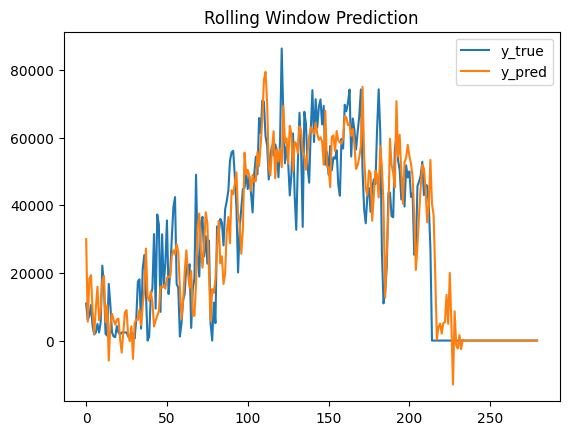

In [55]:
pred_df[['y_true', 'y_pred']].plot(title='Rolling Window Prediction')

In [56]:
y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

In [57]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
)

In [58]:
mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

In [59]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))

In [60]:
# Relative / % metrics
mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

In [61]:
r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

In [62]:
metrics = pd.Series({
    "MSE": mse,
    "RMSE": np.sqrt(mse),
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs,
})

In [63]:
print("\n=== Model Evaluation (Rolling Predictions) ===")
display(metrics.to_frame("value"))


=== Model Evaluation (Rolling Predictions) ===


,value
MSE,1.124301e+08
RMSE,1.060331e+04
MAE,7.404577e+03
MedianAE,5.356579e+03
MaxAE,4.045974e+04
MAPE (%),7.879682e+12
sMAPE (%),4.482554e+01
R2,8.159627e-01
ExplainedVariance,8.166541e-01


# Generalization for all Data

In [64]:
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []

for i in range (1, 101):
    file_path = "processed_timeseries_table_timeseries_table (" + str(i) + ").csv"
    
    # Load the latest version
    df = kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      "lsobieski/processed-thermostat-data",
      file_path,
    )
    
    df.head()
    
    df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Date'] = df['Timestamp'].dt.date
    
    daily_data = df.groupby('Date').agg(
        #should have a check for if running from before midnight to next day
        runtime_start=('CumulativeRuntime', 'first'),
        runtime_end=('CumulativeRuntime', 'last'),
    
        avg_setpoint=('Setpoint', 'mean'),
        #fix this through interpolation later but for now ok
        temp_at_midnight=('Temperature', 'first'),
        #
        outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
        outdoor_humidity_at_midnight=('outsideHumidity', 'first'),
        timestamp_first=('Timestamp', 'first'),
        timestamp_last=('Timestamp', 'last'),
    )
    
    daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]
    
    for i in range(1, len(daily_data)):
        today = daily_data.iloc[i]
        prev = daily_data.iloc[i - 1]
    
        if today['runtime_start'] > prev['runtime_end']:
            
            midnight_today = pd.Timestamp(today.name)  
            midnight_prev = midnight_today
            
            prev_last_ts = prev['timestamp_last']
            today_first_ts = today['timestamp_first']
            
            prev_missing = (midnight_prev - prev_last_ts).total_seconds()
            today_missing = (today_first_ts - midnight_today).total_seconds()
            
            daily_data.iloc[i - 1, daily_data.columns.get_loc('daily_runtime')] += prev_missing
            daily_data.iloc[i, daily_data.columns.get_loc('daily_runtime')] += today_missing


    daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end", "timestamp_first", "timestamp_last"])
    daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days

    
    groups = (daily_data['day_gap'] > 1).cumsum()
    largest_group = groups.value_counts().idxmax()
    daily_data = daily_data[groups == largest_group]

    target = 'daily_runtime'

    daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)

    daily_data = daily_data.dropna()

    X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
    y = daily_data['daily_runtime'].values
    dates = daily_data.index
    
    windows = []

    if len(daily_data) < window_size:
        print(i)
        continue
    
    for end in range(window_size, len(daily_data) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
        
        test_date = dates[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []

    for X_train, y_train, X_test, y_test, test_date in windows:
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)[0]
        
        predictions.append({
            'Date': test_date,
            'y_true': y_test[0],
            'y_pred': y_pred
        })
        
    pred_df = pd.DataFrame(predictions)

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])

    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  2.701000e+32
RMSE                 2.370341e+15
MAE                  1.147103e+14
MedianAE             5.627072e+03
MaxAE                4.947631e+16
MAPE (%)             6.107255e+12
sMAPE (%)            5.772323e+01
R2                  -8.017938e+23
ExplainedVariance   -7.999126e+23
dtype: float64


In [65]:
print(r2_list)

[0.6306813181097146, -0.12359400012757615, 0.825138238280525, -2.7097851336647856, 0.5456816847687084, 0.2925141311632117, 0.36065722236469466, 0.13534148470700358, 0.6327191769185574, 0.8159627341854339, 0.38680953104125526, 0.3462900540609193, 0.42926383252260647, 0.1621628388574311, 0.11152301578035018, 0.17823038952417825, 0.6682696363382208, 0.21853041687914887, 0.19515249414792946, 0.5349732743973329, 0.11045391649826097, -0.16100291228545482, -0.21879558947479616, 0.41887073524282337, 0.7706835079445498, 0.5511248820992335, 0.3935604252586232, -152.98986125118097, 0.597780293031444, -0.4283223752994527, 0.5766677596257679, 0.41469128723035964, 0.2421801512656907, -0.3984362482226025, 0.06918965773743058, -0.008876238452194318, 0.5970036783595942, 0.483668921762465, 0.5345276674772507, 0.012593817177928734, -0.06262225893698847, -0.0025061697800716765, 0.1453956797761612, 0.007445863604768843, 0.31594322423201504, 0.09047529756677009, 0.43661242857434035, 0.13860104406134555, 0.5

In [66]:
#looked at data for r^2 with wild outliers
#these outliers are created by "bad data" where the fan state (used to calculate runtime) isnt tracked properly
outlier_indices = [i for i, val in enumerate(r2_list) if val < -5]

In [67]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  3.608286e+08
RMSE                 1.489651e+04
MAE                  8.646196e+03
MedianAE             5.519498e+03
MaxAE                1.182930e+05
MAPE (%)             5.543569e+12
sMAPE (%)            5.729131e+01
R2                   3.823311e-01
ExplainedVariance    3.855511e-01
dtype: float64


<Axes: ylabel='Count'>

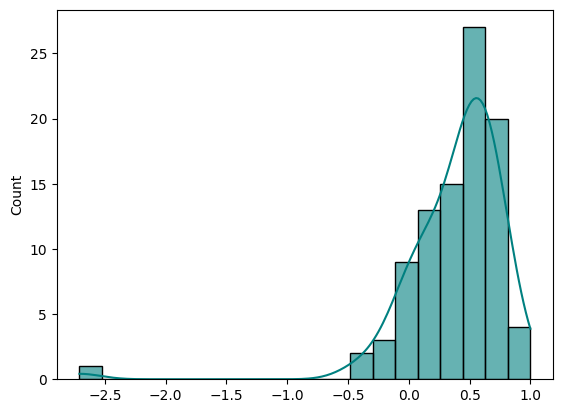

In [68]:
import seaborn as sns
sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

In [ ]:
#still a couple outliers due to bad data, but better

# Window Size Testing

In [70]:
for window_size in [1, 7, 14, 21, 28, 35]:
    print("Testing with Rolling Window Size:", str(window_size))
    mse_list = []
    rmse_list = []
    mae_list = []
    medae_list = []
    maxae_list = []
    mape_list = []
    smape_list = []
    r2_list = []
    evs_list = []
    
    for i in range (1, 101):
        file_path = "processed_timeseries_table_timeseries_table (" + str(i) + ").csv"
        
        # Load the latest version
        df = kagglehub.dataset_load(
          KaggleDatasetAdapter.PANDAS,
          "lsobieski/processed-thermostat-data",
          file_path,
        )
        
        df.head()
        
        df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Date'] = df['Timestamp'].dt.date
        
        daily_data = df.groupby('Date').agg(
            #should have a check for if running from before midnight to next day
            runtime_start=('CumulativeRuntime', 'first'),
            runtime_end=('CumulativeRuntime', 'last'),
        
            avg_setpoint=('Setpoint', 'mean'),
            #fix this through interpolation later but for now ok
            temp_at_midnight=('Temperature', 'first'),
            #
            outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
            outdoor_humidity_at_midnight=('outsideHumidity', 'first'),
            timestamp_first=('Timestamp', 'first'),
            timestamp_last=('Timestamp', 'last'),
        )
        
        daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]
        
        for i in range(1, len(daily_data)):
            today = daily_data.iloc[i]
            prev = daily_data.iloc[i - 1]
        
            if today['runtime_start'] > prev['runtime_end']:
                
                midnight_today = pd.Timestamp(today.name)  
                midnight_prev = midnight_today
                
                prev_last_ts = prev['timestamp_last']
                today_first_ts = today['timestamp_first']
                
                prev_missing = (midnight_prev - prev_last_ts).total_seconds()
                today_missing = (today_first_ts - midnight_today).total_seconds()
                
                daily_data.iloc[i - 1, daily_data.columns.get_loc('daily_runtime')] += prev_missing
                daily_data.iloc[i, daily_data.columns.get_loc('daily_runtime')] += today_missing
        
            
        daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end", "timestamp_first", "timestamp_last"])
        daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days
    
        
        groups = (daily_data['day_gap'] > 1).cumsum()
        largest_group = groups.value_counts().idxmax()
        daily_data = daily_data[groups == largest_group]
    
        target = 'daily_runtime'
    
        daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)
    
        daily_data = daily_data.dropna()
    
        X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
        y = daily_data['daily_runtime'].values
        dates = daily_data.index
        
        windows = []
    
        if len(daily_data) < window_size:
            print(i)
            continue
        
        for end in range(window_size, len(daily_data) - 1 + 1):
            start = end - window_size
        
            X_train = X[start:end]
            y_train = y[start:end]
            
            X_test = X[end:end + 1]
            y_test = y[end:end + 1]
            
            test_date = dates[end]
            
            windows.append((X_train, y_train, X_test, y_test, test_date))
    
        predictions = []
    
        for X_train, y_train, X_test, y_test, test_date in windows:
            model = LinearRegression()
            model.fit(X_train, y_train)
            
            y_pred = model.predict(X_test)[0]
            
            predictions.append({
                'Date': test_date,
                'y_true': y_test[0],
                'y_pred': y_pred
            })
            
        pred_df = pd.DataFrame(predictions)
    
        mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
        y_true = pred_df["y_true"].to_numpy()
        y_pred = pred_df["y_pred"].to_numpy()
    
        mae = mean_absolute_error(y_true, y_pred)
        medae = np.median(np.abs(y_true - y_pred))
        maxae = np.max(np.abs(y_true - y_pred))
    
        mape_val = mape(y_true, y_pred)
        smape_val = smape(y_true, y_pred)
    
        r2 = r2_score(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
    
        mse_list.append(mse)
        rmse_list.append(np.sqrt(mse))
        mae_list.append(mae)
        medae_list.append(medae)
        maxae_list.append(maxae)
        mape_list.append(mape_val)
        smape_list.append(smape_val)
        r2_list.append(r2)
        evs_list.append(evs)
    
    avg_metrics = pd.Series({
        "MSE": np.mean(mse_list),
        "RMSE": np.mean(rmse_list),
        "MAE": np.mean(mae_list),
        "MedianAE": np.mean(medae_list),
        "MaxAE": np.mean(maxae_list),
        "MAPE (%)": np.mean(mape_list),
        "sMAPE (%)": np.mean(smape_list),
        "R2": np.mean(r2_list),
        "ExplainedVariance": np.mean(evs_list),
    })
    
    outlier_indices = [i for i, val in enumerate(r2_list) if val < -5]
    
    print(len(outlier_indices))
    
    all_metric_lists = {
        "mse": mse_list,
        "rmse": rmse_list,
        "mae": mae_list,
        "medae": medae_list,
        "maxae": maxae_list,
        "mape": mape_list,
        "smape": smape_list,
        "r2": r2_list,
        "evs": evs_list
    }
    
    filtered_data = {
        name: [val for i, val in enumerate(lst) if i not in outlier_indices]
        for name, lst in all_metric_lists.items()
    }
    
    mse_list = filtered_data["mse"]
    rmse_list = filtered_data["rmse"]
    mae_list = filtered_data["mae"]
    medae_list = filtered_data["medae"]
    maxae_list = filtered_data["maxae"]
    mape_list = filtered_data["mape"]
    smape_list = filtered_data["smape"]
    r2_list = filtered_data["r2"]
    evs_list = filtered_data["evs"]
    
    avg_metrics = pd.Series({
        "MSE": np.mean(mse_list),
        "RMSE": np.mean(rmse_list),
        "MAE": np.mean(mae_list),
        "MedianAE": np.mean(medae_list),
        "MaxAE": np.mean(maxae_list),
        "MAPE (%)": np.mean(mape_list),
        "sMAPE (%)": np.mean(smape_list),
        "R2": np.mean(r2_list),
        "ExplainedVariance": np.mean(evs_list),
    })
    
    print(avg_metrics)

Testing with Rolling Window Size: 1
0
MSE                  2.403086e+08
RMSE                 1.198493e+04
MAE                  7.220308e+03
MedianAE             4.460005e+03
MaxAE                6.990035e+04
MAPE (%)             2.091449e+12
sMAPE (%)            4.659092e+01
R2                   5.930701e-01
ExplainedVariance    5.932057e-01
dtype: float64
Testing with Rolling Window Size: 7
33
MSE                  8.257752e+08
RMSE                 2.397699e+04
MAE                  1.163897e+04
MedianAE             6.050049e+03
MaxAE                2.254409e+05
MAPE (%)             6.344733e+12
sMAPE (%)            6.727546e+01
R2                  -7.412289e-01
ExplainedVariance   -7.358777e-01
dtype: float64
Testing with Rolling Window Size: 14
15
MSE                  4.070828e+08
RMSE                 1.612747e+04
MAE                  8.809204e+03
MedianAE             5.473965e+03
MaxAE                1.442389e+05
MAPE (%)             5.244490e+12
sMAPE (%)            5.847513e+01
R2 

We see improved r^2, MSE, RMSE, MAE, etc as we continue to increase the window size up to 21, with the exception of RW 1 which is essentially a naive model which takes the previous day's data and predicts for the current day. In addition, the number of datasets which are dropped for being outliers (R^2 < -5, which indicates bad data) decrease as we increase the window size.